# Phase 2a — The real thing: a quantum twin of TmMgGaO₄

**CERN QTI Hackathon — Quantum twin of TmMgGaO₄**

We now map the triangular-lattice frustrated magnet TmMgGaO₄ onto a
Rydberg array and reproduce the central result of Fig. 1 of
[Leclerc et al., arXiv:2603.20372](https://arxiv.org/abs/2603.20372):
the magnetisation curve M^z(Δ_z/J₁) across the paramagnet → 1/3-order
antiferromagnetic quantum phase transition.

All of the physics (Hamiltonian mapping, register construction, pulse
sequences) lives in `src/material_mapping.py` — see the module docstring
there for the full derivation of Eq. 4 of the paper. In short:

```
Delta_x(t) = Omega(t) / 2
Delta_z(t) = (delta_U - delta(t)) / 2,   delta_U ~= 12 * J1   (bulk, 6 NN)
J1 = C6 / (4 * r1^6)
```

**Strategy.** Rather than repeating many independent ground-state
preparations at fixed Δ_z (one per point on the curve, as the paper
does for cross-checks), we run a *single* quasi-adiabatic sweep of
δ(t) — exactly as in Ext. Dat. Fig. 4a — and record ⟨M^z(t)⟩ along the
way. Converting t → Δ_z(t)/J₁ via the mapping above turns one
simulation into a full magnetisation curve.


In [ ]:
import sys, time
sys.path.insert(0, "../src")
import numpy as np
import matplotlib.pyplot as plt

import material_mapping as mm
import emu_mps

np.set_printoptions(precision=3, suppress=True)


## 1. Device, register and the material → QPU mapping

We reproduce Pasqal's FM1 device (`|75 S_1/2, m_J=1/2>`, r1 = 9 μm),
which the paper used for the majority of the reported data.

The register is the paper's rhombus construction (Ext. Dat. Fig. 3 /
Methods): an `L x L` rhombus with the outer `buffer_rows` used only to
suppress edge effects; observables are averaged over the inner bulk.

For a fast CPU demo we use a small bulk (`l_bulk=3`, one buffer row
-> N=25). **The paper's smallest reported system is N=49
(l_bulk=3, buffer_rows=2)** — bump `buffer_rows` to 2 and `l_bulk` up to
6, 9, 12 (N=100, 169, 256) once you're running on a GPU with `emu_mps`.


hbar*J1 / 2pi = 0.9165 MHz  (paper quotes ~0.925 MHz from U1/(2pi hbar)=3.7 MHz)
N = 25 atoms, 9 in the bulk region


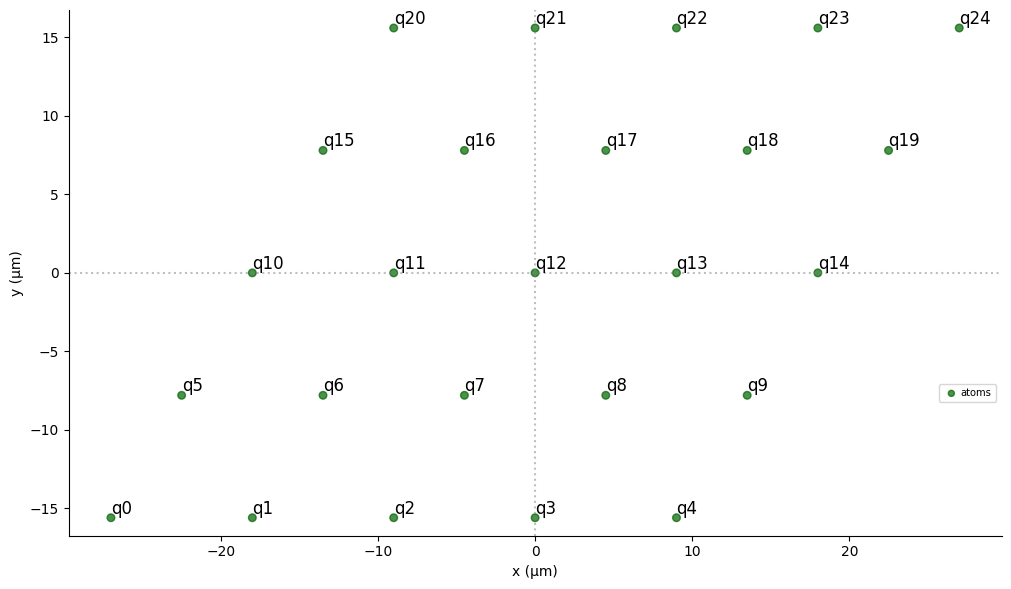

In [2]:
device = mm.build_device(rydberg_level=75, min_atom_distance=4.0)
r1 = 9.0  # um, paper's FM1 nearest-neighbour spacing
J1 = mm.j1_from_device(device, r1)
print(f"hbar*J1 / 2pi = {J1/(2*np.pi):.4f} MHz  (paper quotes ~0.925 MHz from U1/(2pi hbar)=3.7 MHz)")

l_bulk, buffer_rows = 3, 1     # -> N=25 (fast CPU demo). Paper: buffer_rows=2 -> N=49.
register, is_bulk = mm.triangular_rhombus_register(l_bulk, r1, buffer_rows=buffer_rows)
print(f"N = {len(register.qubits)} atoms, {is_bulk.sum()} in the bulk region")

register.draw()


## 2. Quasi-adiabatic sweep across the transition

We sweep Δ_z/J₁ from deep in the paramagnet (Δ_z/J₁ = 10, matching the
paper's high-field limit) down into the 1/3-ordered phase (Δ_z/J₁ = 1),
at the material's own transverse field Δ_x/J₁ = 1.08 (Ω_max/2π ≈ 2 MHz,
matching the paper's protocol exactly — see `Omega_max_over_J1` below).


In [3]:
Delta_z_start, Delta_z_end = 10.0, 1.0
seq = mm.quasi_adiabatic_material_sweep(
    register, device, J1,
    Omega_max_over_J1=1.08,           # matches the material's Delta_x/J1
    Delta_z_start_over_J1=Delta_z_start,
    Delta_z_end_over_J1=Delta_z_end,
    t_rise=200, t_sweep=1200, t_fall=200,
)
print(f"Sequence duration: {seq.get_duration()} ns")


Sequence duration: 1600 ns


## 3. Run with `emu_mps`, at two bond dimensions (convergence check)

The evaluation-criteria table for this challenge explicitly asks for
bond-dimension convergence to be checked ("at least two values of D").
We do that here with `max_bond_dim = 12` and `24`; scale both up once you
have GPU headroom, and add a third, larger value.


In [4]:
def run_sweep(max_bond_dim, n_points=24):
    from emu_mps import MPSBackend, MPSConfig, Occupation
    eval_times = list(np.linspace(0.03, 1.0, n_points))
    cfg = MPSConfig(dt=20.0, max_bond_dim=max_bond_dim,
                     observables=[Occupation(evaluation_times=eval_times)])
    t0 = time.time()
    backend = MPSBackend(seq, config=cfg)
    res = backend.run()
    print(f"  D={max_bond_dim}: {time.time()-t0:.1f} s")
    occs = [np.array(o) for o in res.occupation]
    Mz = np.array([mm.bulk_magnetisation(o, is_bulk) for o in occs])
    t_ns = np.array(eval_times) * seq.get_duration()
    return t_ns, Mz

bond_dims = [12, 24]
sweep_results = {}
for D in bond_dims:
    sweep_results[D] = run_sweep(D)


step = 1/103, χ = 1, |ψ| = 0.001 MB, RSS = 652.084 MB, Δt = 0.227 s


step = 2/103, χ = 2, |ψ| = 0.003 MB, RSS = 652.340 MB, Δt = 0.256 s


step = 3/103, χ = 2, |ψ| = 0.003 MB, RSS = 652.852 MB, Δt = 0.336 s


step = 4/103, χ = 2, |ψ| = 0.003 MB, RSS = 652.852 MB, Δt = 0.335 s


step = 5/103, χ = 4, |ψ| = 0.007 MB, RSS = 652.852 MB, Δt = 0.437 s


...

step = 100/103, χ = 24, |ψ| = 0.312 MB, RSS = 660.204 MB, Δt = 0.832 s


step = 101/103, χ = 24, |ψ| = 0.312 MB, RSS = 660.204 MB, Δt = 1.069 s


step = 102/103, χ = 24, |ψ| = 0.312 MB, RSS = 660.332 MB, Δt = 1.103 s


step = 103/103, χ = 24, |ψ| = 0.312 MB, RSS = 660.332 MB, Δt = 1.076 s


  D=24: 81.2 s


## 4. Convert time → Δ_z/J₁ and plot the magnetisation curve

The δ(t) waveform is linear in time by construction, so t → Δ_z(t)/J₁ is
an affine map; we invert it directly (no need to re-simulate).


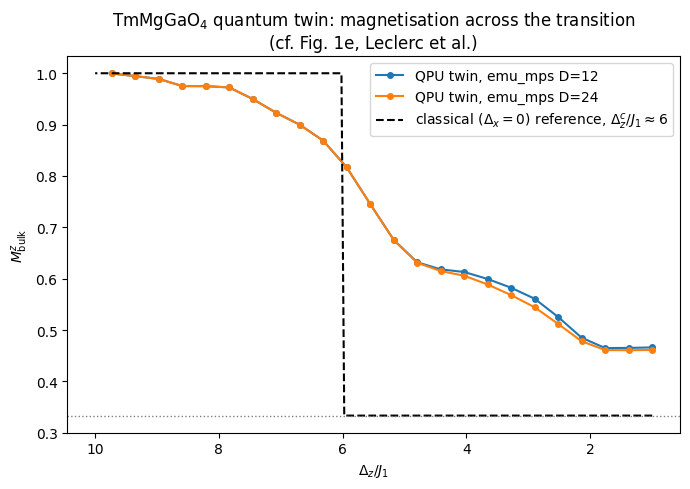

In [5]:
def time_to_Delta_z(t_ns, total_ns):
    frac = t_ns / total_ns
    return Delta_z_start + frac * (Delta_z_end - Delta_z_start)

total_ns = seq.get_duration()

fig, ax = plt.subplots(figsize=(7, 5))
for D, (t_ns, Mz) in sweep_results.items():
    Dz = time_to_Delta_z(t_ns, total_ns)
    ax.plot(Dz, Mz, "-o", ms=4, label=f"QPU twin, emu_mps D={D}")

Dz_ref = np.linspace(Delta_z_end, Delta_z_start, 200)
ax.plot(Dz_ref, mm.classical_Mz(Dz_ref), "k--", lw=1.5,
        label=r"classical ($\Delta_x=0$) reference, $\Delta_z^c/J_1\approx6$")
ax.axhline(1/3, color="gray", ls=":", lw=1)
ax.set_xlabel(r"$\Delta_z / J_1$")
ax.set_ylabel(r"$M^z_{\mathrm{bulk}}$")
ax.set_title("TmMgGaO$_4$ quantum twin: magnetisation across the transition\n(cf. Fig. 1e, Leclerc et al.)")
ax.invert_xaxis()
ax.legend()
plt.tight_layout()
plt.savefig("phase2a_magnetisation_curve.png", dpi=140)
plt.show()


## 5. Digitised material data (to overlay)

To fully reproduce Fig. 1e you need the experimental
`M^z_AC(Δ_z/J1)` curve from the paper's AC-susceptibility measurements
(their Fig. 1e / Eq. 2). **We deliberately do not fabricate those data
points here** — digitise them yourself from the published figure (e.g.
with WebPlotDigitizer) or, if you have journal access, request the
source data, and drop them into `material_data.csv` with columns
`Delta_z_over_J1, Mz_AC`. The cell below will overlay them automatically
if the file is present.


In [6]:
import os
if os.path.exists("material_data.csv"):
    import csv
    dz_data, mz_data = [], []
    with open("material_data.csv") as f:
        for row in csv.DictReader(f):
            dz_data.append(float(row["Delta_z_over_J1"]))
            mz_data.append(float(row["Mz_AC"]))
    ax.plot(dz_data, mz_data, "s", color="crimson", ms=3, label="TmMgGaO4 AC susceptibility (digitised)")
    ax.legend()
    fig
else:
    print("material_data.csv not found -- skipping experimental overlay (see markdown above).")


material_data.csv not found -- skipping experimental overlay (see markdown above).


## 6. Estimating the quantum critical point

Following the paper's Methods (cubic-polynomial-fit approach on
`M^z_QPU(Δ_z/J1)`), we locate `Δ_z^q/J1` as the field where |dM^z/dΔ_z|
peaks, using the finest (largest-D) sweep.


In [7]:
D_best = max(bond_dims)
t_ns, Mz = sweep_results[D_best]
Dz = time_to_Delta_z(t_ns, total_ns)
order = np.argsort(Dz)
Dz_sorted, Mz_sorted = Dz[order], Mz[order]

# Fit a cubic over the expected transition window, as in the paper's Methods
mask = (Dz_sorted > 2) & (Dz_sorted < 6)
if mask.sum() >= 4:
    coeffs = np.polyfit(Dz_sorted[mask], Mz_sorted[mask], 3)
    dz_fine = np.linspace(Dz_sorted[mask].min(), Dz_sorted[mask].max(), 400)
    dMdz = np.polyval(np.polyder(np.poly1d(coeffs)), dz_fine)
    Dz_crit = dz_fine[np.argmax(np.abs(dMdz))]
    print(f"Estimated quantum critical point: Delta_z^q / J1 ~= {Dz_crit:.2f}")
    print("(paper reports Delta_z^q/J1(N=256) = 3.87 +0.44/-0.36)")
else:
    print("Not enough points in the fit window at this system size/sweep -- "
          "use more evaluation_times or a wider window.")


Estimated quantum critical point: Delta_z^q / J1 ~= 5.93
(paper reports Delta_z^q/J1(N=256) = 3.87 +0.44/-0.36)


## Notes on scaling up / what to change for the real Fig. 1

1. **System size.** Set `l_bulk=3, buffer_rows=2` (N=49, the paper's
   smallest system) as a first GPU run, then `l_bulk=6` (N=100),
   `l_bulk=9` (N=169) to see the critical-point estimate sharpen, as
   Fig. 2d of the paper shows explicitly.
2. **Bond dimension.** The paper finds `D=256` still not fully converged
   for their largest system (Fig. S2) — always report your bond-dimension
   scan alongside the magnetisation curve, exactly as done in cell 4
   above.
3. **Multiple independent point-by-point ground states** (rather than one
   continuous sweep) is closer to what the paper's Fig. 2c does for the
   magnetisation and is easy to build from `mm.qpu_controls_from_material`
   directly if you want a slower-but-more-adiabatic curve per point.
